In [54]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

In [ ]:
from functions import dL_rosenbrock_1d
import pandas as pd
from src.optimizer import AdamScratch1D, NonlocalSolverMomentumAdam
from src.utils import AdamPlotter
import matplotlib.pyplot as plt
import numpy as np
from config import *

# CONTINUOUS ADAM

In [60]:
def dL_wrapper(theta):
    return dL_rosenbrock_1d(theta, (a,))

In [ ]:
print("Resolviendo theta1...")
optimizer_theta = NonlocalSolverMomentumAdam(
    dL=dL_wrapper,
    t_span=(lr, 10.0),
    y0=[initial_theta, 0.0],
    alpha=lr,
    betas=(beta1, beta2),
    eps_base=epsilon,
    verbose=True,
    quad_order=50
)
t, y = optimizer_theta.solve()

if y.ndim == 1:
    # Equation of firs orden: y contains directly theta
    theta_history = y
    theta_dot_history = None  # No exists for first order equation
    final_state = theta_history[-1]
    print(f"\nFinal value of theta: {float(final_state):.6e}")
else:
    # Second order equation: y has columns [theta, theta_dot]
    theta_history = y[:, 0]
    theta_dot_history = y[:, 1]
    final_state = theta_history[-1]
    if isinstance(final_state, np.ndarray) and final_state.size > 1:
        print(f"\nFinal value of theta: {final_state[0]:.6e}")
        print(f"Final velocity: {final_state[1]:.6e}")
    else:
        print(f"\nFinal value of theta: {float(final_state):.6e}")

print(f"Final time: {t[-1]}")
print(f"Number of steps: {len(t)}")

Resolviendo theta1...
Second order equation --> using sinh/sin kernels
ParallelComputation: joblib backend='loky', workers=23/24

Building functional RHS (iteration 0)...
¿No finitos en y?: False (NaN: False, Inf: False)

--- DEBUG interpolador ---
y_pos shape: (9999,), dtype: float64
y_pos[:5]: [5. 5. 5. 5. 5.]
y_pos finitos: True
--- FIN DEBUG ---

Computing moments for 9999 time points...
  Parallel execution: 9999 items → 23 workers (joblib/loky)
Moments computed in 1.52s
m[0]=0.000e+00, v[0]=0.000e+00
m[1]=2.731e+01, v[1]=1.352e+02
m[-1]=5.164e+02, v[-1]=2.383e+05
Iter 0 – err 608.6270129216477

Building functional RHS (iteration 1)...
¿No finitos en y?: False (NaN: False, Inf: False)

--- DEBUG interpolador ---
y_pos shape: (9999,), dtype: float64
y_pos[:5]: [5.         5.         4.99944723 4.99925156 4.99860662]
y_pos finitos: True
--- FIN DEBUG ---

Computing moments for 9999 time points...
  Parallel execution: 9999 items → 23 workers (joblib/loky)
Moments computed in 1.67s
m

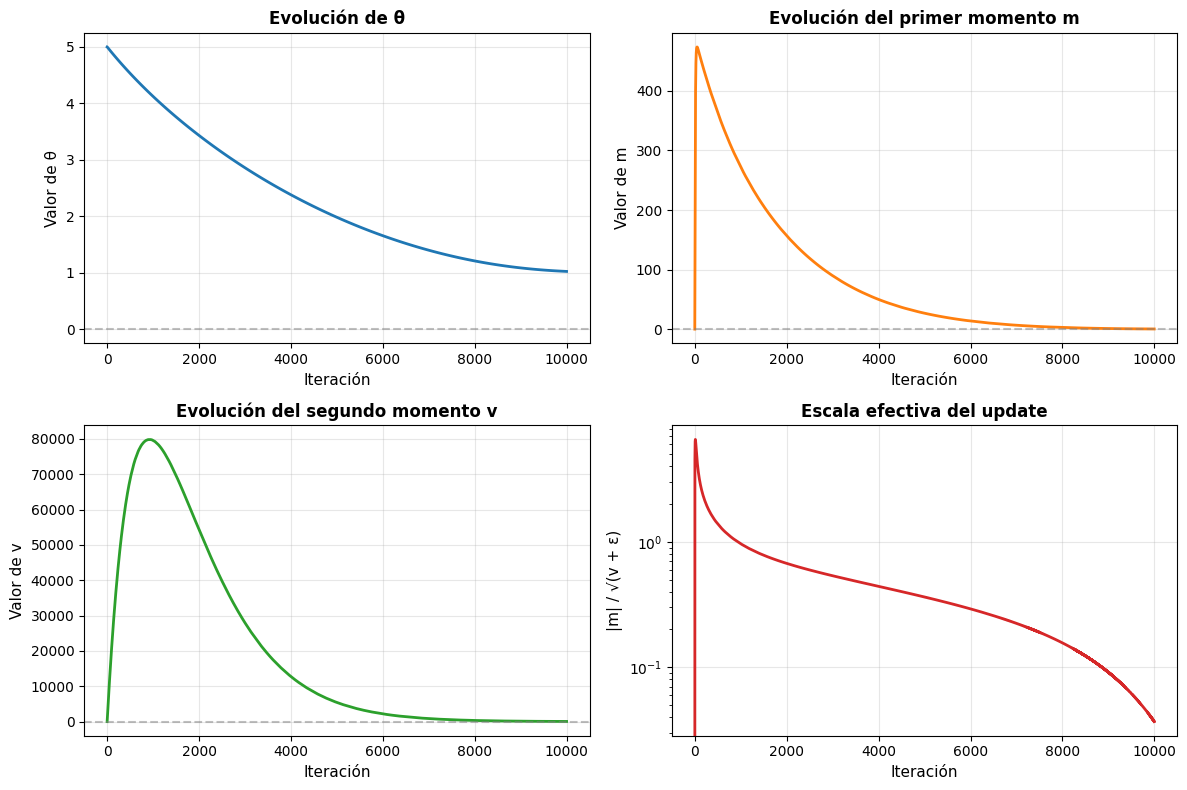

In [62]:
# Crear el plotter y visualizar
plotter = AdamPlotter(theta_history, optimizer_theta._last_m[:, 1], optimizer_theta._last_v[:, 1])

# Plotear todo
plotter.plot('all')
plt.show()

# Save Results

In [ ]:
# Create DataFrame
df_continuous = pd.DataFrame({
    't': np.arange(len(theta_history)),
    'theta_history': theta_history,
    'm_history': optimizer_theta._last_m[:, 1],
    'v_history': optimizer_theta._last_v[:, 1]
})

# Save to CSV
df_continuous.to_csv(f'results_2nd_order/continuous_adam_results_lr_{lr}_beta1_{beta1}_beta2_{beta2}.csv', index=False)
print(f"Results saved in 'results_2nd_order/continuous_adam_results.csv'")
print(f"Total rows: {len(df_continuous)}")

Results saved in 'results/continuous_adam_results.csv'
Total rows: 9999
